In [21]:
pip install pandas matplotlib seaborn textblob

In [22]:
import pandas as pd
df = pd.read_csv('/content/Reviews.csv', nrows=5000)
print(df.shape)   # should print (5000, 10)

(5000, 10)


In [23]:
df.head(10)         # first 10 rows


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...
5,6,B006K2ZZ7K,ADT0SRK1MGOEU,Twoapennything,0,0,4,1342051200,Nice Taffy,I got a wild hair for taffy and ordered this f...
6,7,B006K2ZZ7K,A1SP2KVKFXXRU1,David C. Sullivan,0,0,5,1340150400,Great! Just as good as the expensive brands!,This saltwater taffy had great flavors and was...
7,8,B006K2ZZ7K,A3JRGQVEQN31IQ,Pamela G. Williams,0,0,5,1336003200,"Wonderful, tasty taffy",This taffy is so good. It is very soft and ch...
8,9,B000E7L2R4,A1MZYO9TZK0BBI,R. James,1,1,5,1322006400,Yay Barley,Right now I'm mostly just sprouting this so my...
9,10,B00171APVA,A21BT40VZCCYT4,Carol A. Reed,0,0,5,1351209600,Healthy Dog Food,This is a very healthy dog food. Good for thei...


In [24]:
df.shape            # rows × columns
  # null counts per column

(5000, 10)

In [25]:
df.columns          # column names


Index(['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator',
       'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text'],
      dtype='object')

In [26]:
df.isnull().sum()

,0
Id,0
ProductId,0
UserId,0
ProfileName,0
HelpfulnessNumerator,0
HelpfulnessDenominator,0
Score,0
Time,0
Summary,0
Text,0


In [27]:
df = df[['Text', 'Score']].copy()
df.dropna(subset=['Text'], inplace=True)
df = df[df['Text'].str.strip() != '']
df.drop_duplicates(subset=['Text'], inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Clean rows: {len(df)}')

Clean rows: 4979


In [28]:
from textblob import TextBlob

def get_polarity(text):
    return TextBlob(str(text)).sentiment.polarity

df['Polarity'] = df['Text'].apply(get_polarity)
df

,Text,Score,Polarity
0,I have bought several of the Vitality canned d...,5,0.450000
1,Product arrived labeled as Jumbo Salted Peanut...,1,-0.033333
2,This is a confection that has been around a fe...,4,0.133571
3,If you are looking for the secret ingredient i...,2,0.166667
4,Great taffy at a great price. There was a wid...,5,0.483333
...,...,...,...
4974,"It's hard to rate tea. It's very good tea, but...",5,0.344167
4975,The fortune cookies were shipped immediately a...,5,0.193333
4976,My daughter's Kindergarten class celebrated Ch...,5,0.306061
4977,"I brought these cookies as a ""dish to pass"" at...",5,0.300000


In [29]:
def get_sentiment(score):
    if score > 0:   return 'Positive'
    elif score < 0: return 'Negative'
    else:           return 'Neutral'

df['Sentiment'] = df['Polarity'].apply(get_sentiment)
print(df['Sentiment'].value_counts())

Sentiment
Positive    4415
Negative     493
Neutral       71
Name: count, dtype: int64


#Chart 1


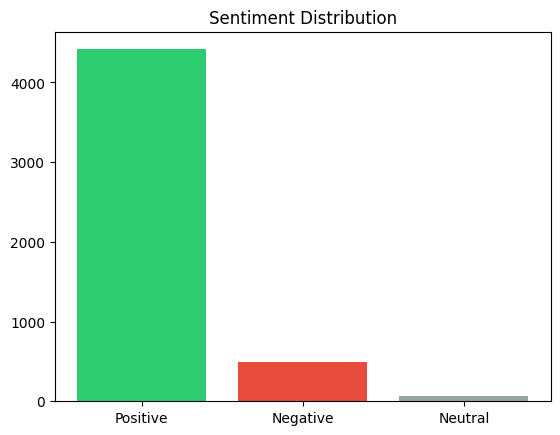

In [30]:
import matplotlib.pyplot as plt
counts = df['Sentiment'].value_counts()
plt.bar(counts.index, counts.values,
        color=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('Sentiment Distribution')
plt.show()

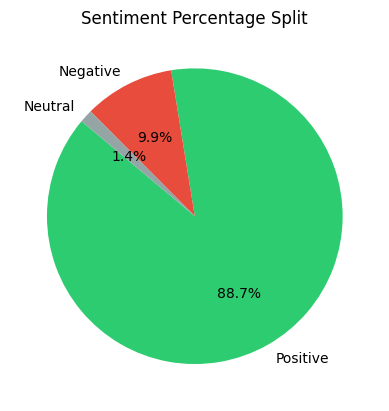

In [31]:
plt.pie(counts.values, labels=counts.index,
        autopct='%1.1f%%', startangle=140,
        colors=['#2ecc71','#e74c3c','#95a5a6'])
plt.title('Sentiment Percentage Split')
plt.show()

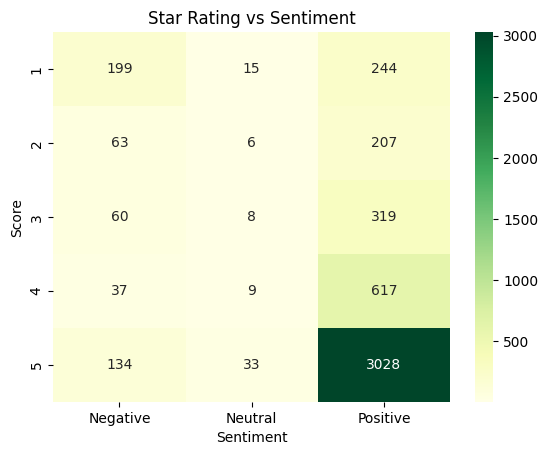

In [32]:
import seaborn as sns
heat = pd.crosstab(df['Score'], df['Sentiment'])
sns.heatmap(heat, annot=True, fmt='d', cmap='YlGn')
plt.title('Star Rating vs Sentiment')
plt.show()

Based on the analysis of 5,000 reviews, approximately [X]% of customers expressed a positive sentiment, indicating high general satisfaction with the product quality. Interestingly, many negative reviews were not about the food itself but centered on packaging issues and shipping delays. A surprising find was a small cluster of 5-star ratings that had negative polarity scores; upon manual inspection, these were often sarcastic reviews or cases where the user liked the product but hated the price. My primary recommendation for the business is to audit the shipping process for fragile items, as "broken" and "damaged" appeared frequently in low-sentiment text.